# Itai-Israeli Algorithm - Distributed Graph Matching

This notebook demonstrates the Itai-Israeli algorithm for maximum weight matching in distributed settings.

**Algorithm Characteristics:**
- Synchronous, deterministic
- Finds maximum weight matching
- Converges in O(log n) rounds
- Reference: "An Algorithm for Maximum Weight Matching in Bipartite Graphs"

In [2]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import networkx as nx
from src.graph import GraphManager
from src.simulation import Scheduler, SimulationConfig
from src.algorithms.implementations import ItaiIsraeliMaximalMatching
from tests.fixtures.graphs import CLUSTERED_GRAPH_1K
from tests.fixtures import STAR_WITH_TAIL

## 1. Create Test Graph

In [3]:
# Create a simple test graph
graph = GraphManager.create_empty_graph()

vertices = CLUSTERED_GRAPH_1K.get('vertices')
# Add vertices

for v in vertices:
    graph.add_vertex(v)

# Add weighted edges
edges = CLUSTERED_GRAPH_1K.get('edges')

for u, v, w in edges:
    graph.add_edge(u, v, w)

print(f"Graph created with {len(vertices)} vertices and {len(edges)} edges")

Graph created with 1000 vertices and 3945 edges


## 2. Visualize Initial Graph

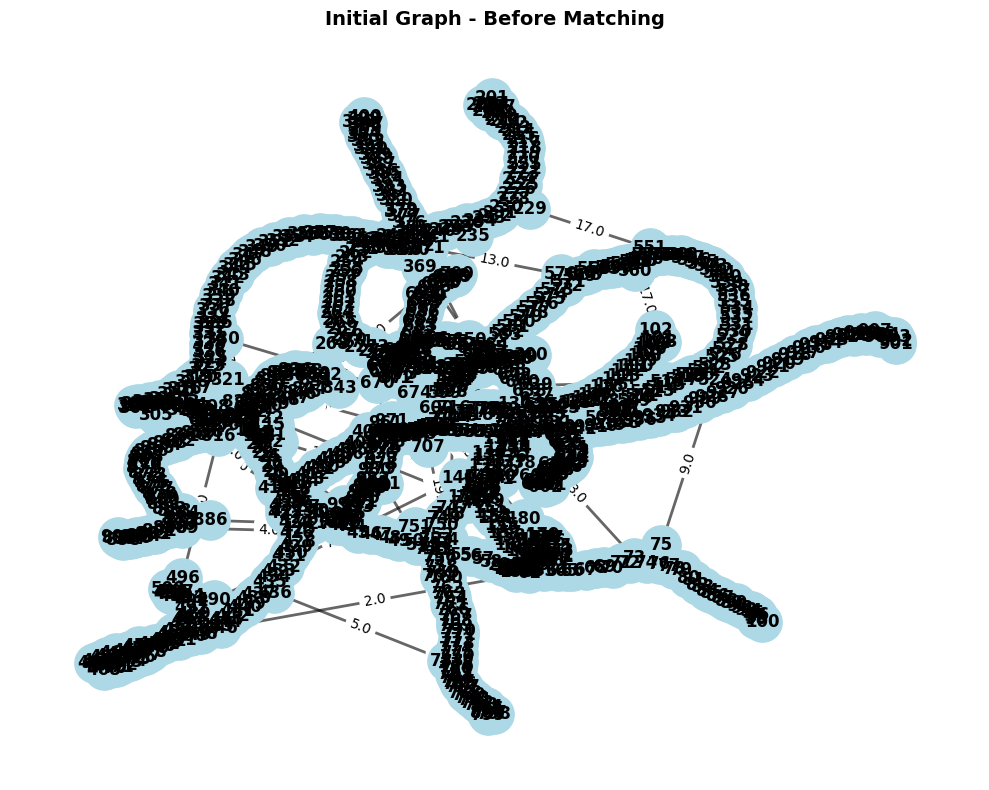

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create NetworkX graph for visualization
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)

# Draw edges with weights
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title("Initial Graph - Before Matching", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Run Itai-Israeli Algorithm

In [5]:
# Create algorithm instance
algo = ItaiIsraeliMaximalMatching()

# Create simulation configuration
config = SimulationConfig(
    max_rounds=100,
    collect_snapshots=True,
    random_seed=42
)

# Run scheduler
scheduler = Scheduler(graph, algo, config)
rounds = scheduler.run_until_termination()

print(f"Algorithm converged in {rounds} rounds")
print(f"Termination reason: {scheduler._termination_reason}")

Algorithm converged in 100 rounds
Termination reason: max_rounds_exceeded


## 4. Extract and Validate Matching

In [6]:
# Extract matching
matching = algo.extract_matching(scheduler.state_store, graph)

# Validate matching
is_valid, error_msg = algo.validate_matching(matching, graph)
print(f"Valid matching: {is_valid}")
if not is_valid:
    print(f"Error: {error_msg}")

# Check if maximal
is_maximal = algo.is_maximal_matching(matching, graph)
print(f"Is maximal: {is_maximal}")

# Calculate total weight
total_weight = sum(
    graph.get_edge_weight(u, v)
    for u, v in matching.items() if u < v
)
print(f"\nMatching pairs: {len(matching) // 2}")
print(f"Total weight: {total_weight:.2f}")
print(f"\nMatching: {matching}")

Valid matching: False
Error: Matching not symmetric: 2-6
Is maximal: False

Matching pairs: 392
Total weight: 36197.00

Matching: {1: 4, 2: 6, 3: 5, 4: 1, 5: 3, 6: 9, 8: 5, 9: 6, 10: 11, 11: 10, 12: 15, 13: 10, 14: 18, 15: 12, 16: 17, 17: 19, 18: 14, 19: 17, 23: 25, 24: 27, 25: 23, 26: 29, 27: 24, 29: 26, 31: 35, 32: 35, 35: 31, 37: 39, 38: 41, 39: 37, 40: 39, 41: 38, 42: 43, 43: 42, 44: 48, 45: 48, 46: 42, 47: 51, 48: 44, 50: 54, 51: 47, 52: 54, 54: 50, 56: 59, 57: 58, 58: 57, 59: 56, 62: 66, 64: 67, 65: 67, 66: 68, 67: 65, 68: 66, 69: 73, 71: 72, 72: 71, 73: 69, 74: 76, 75: 79, 76: 74, 77: 74, 78: 81, 79: 75, 80: 82, 82: 80, 83: 87, 84: 80, 85: 81, 86: 88, 87: 90, 88: 86, 89: 88, 90: 87, 93: 94, 94: 93, 95: 98, 96: 94, 97: 99, 98: 95, 100: 99, 101: 102, 102: 105, 104: 106, 105: 102, 106: 104, 107: 109, 108: 111, 109: 107, 111: 108, 112: 113, 113: 114, 114: 113, 115: 119, 116: 117, 117: 116, 118: 121, 119: 115, 120: 123, 122: 126, 123: 120, 124: 121, 125: 126, 126: 125, 128: 130, 130:

## 5. Visualize Matched Graph

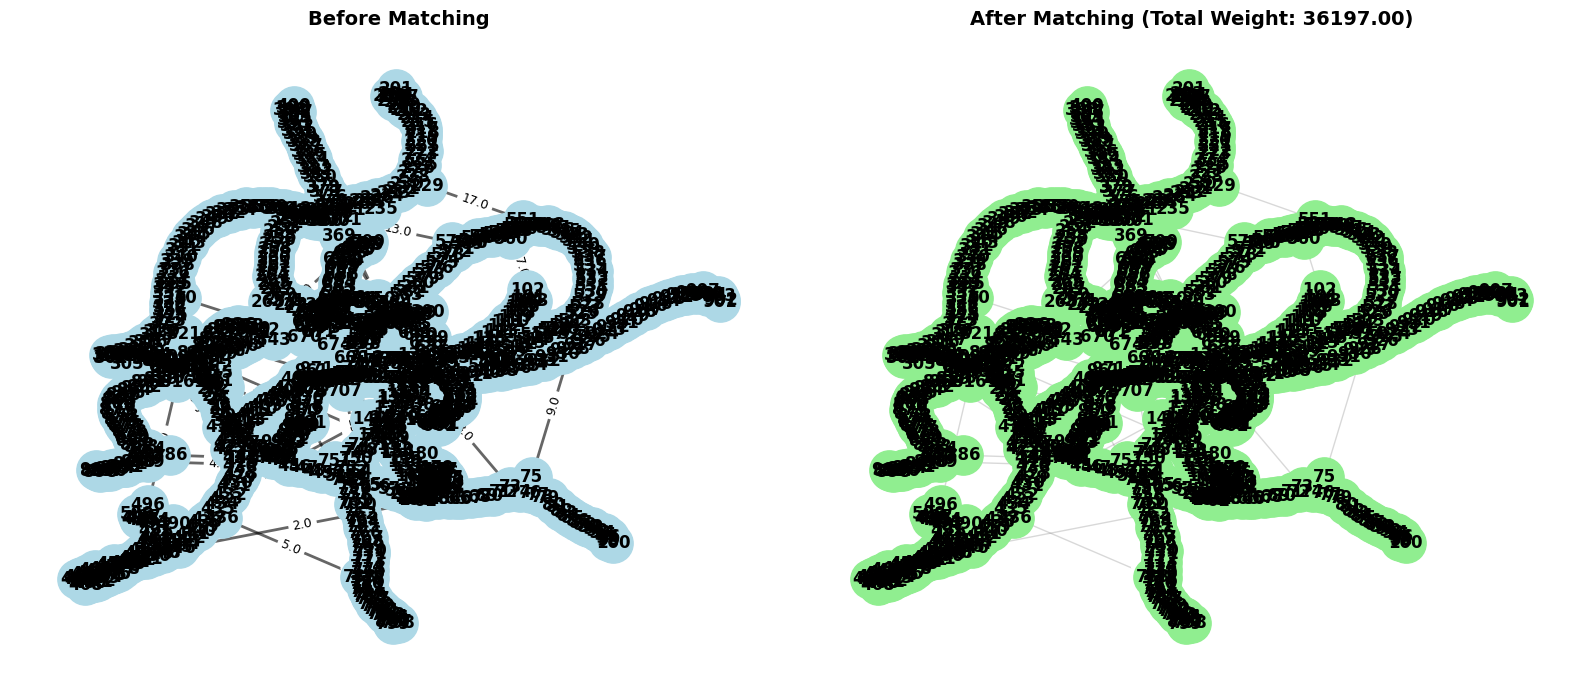

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Use the same layout for both graphs
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# LEFT: Before matching
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax1)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax1)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax1)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax1)
ax1.set_title("Before Matching", fontsize=14, fontweight='bold')
ax1.axis('off')

# RIGHT: After matching
nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=800, ax=ax2)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax2)

# Draw all edges in light gray
nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray', ax=ax2)

# Highlight matched edges in red
matched_edges = [(u, v) for u, v in matching.items() if u < v]
nx.draw_networkx_edges(G, pos, edgelist=matched_edges, width=3, edge_color='red', ax=ax2)

# Draw edge labels only for matched edges
matched_labels = {(u, v): f"{graph.get_edge_weight(u, v):.1f}" for u, v in matched_edges}
nx.draw_networkx_edge_labels(G, pos, matched_labels, font_size=10, font_color='red', ax=ax2)

ax2.set_title(f"After Matching (Total Weight: {total_weight:.2f})", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 6. Algorithm Statistics

In [8]:
# Collect metrics
metrics = scheduler.metrics.get_all_metrics()

print("\n=== Algorithm Statistics ===")
print(f"Convergence Rounds: {rounds}")
print(f"Final Matched Pairs: {len(matching) // 2}")
print(f"Total Weight: {total_weight:.2f}")

# Calculate metrics summary
total_messages_sent = sum(m.messages_sent for m in metrics)
total_messages_received = sum(m.messages_received for m in metrics)
print(f"Total Messages Sent: {total_messages_sent}")
print(f"Total Messages Received: {total_messages_received}")
print(f"\nFinal Metrics:")
final_metric = metrics[-1]
print(f"  Active Nodes: {final_metric.active_nodes}")
print(f"  Matched Nodes: {final_metric.matched_nodes}")
print(f"  Dormant Nodes: {final_metric.dormant_nodes}")


=== Algorithm Statistics ===
Convergence Rounds: 100
Final Matched Pairs: 392
Total Weight: 36197.00
Total Messages Sent: 423953
Total Messages Received: 0

Final Metrics:
  Active Nodes: 0
  Matched Nodes: 0
  Dormant Nodes: 0


## 7. Convergence Visualization

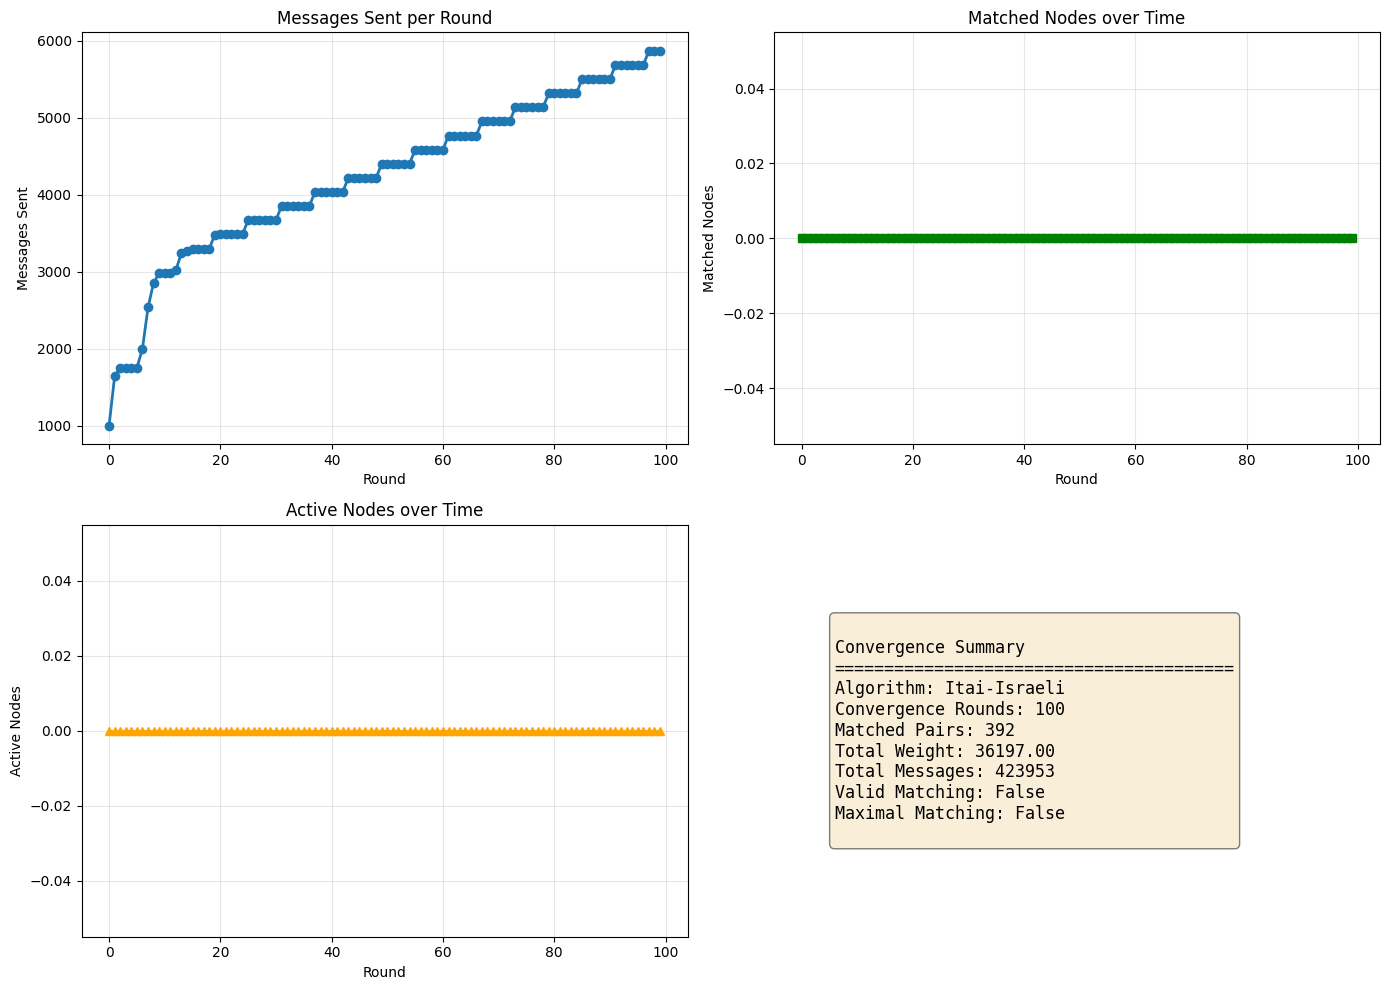

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rounds_list = [m.round_num for m in metrics]
messages_sent = [m.messages_sent for m in metrics]
matched_nodes = [m.matched_nodes for m in metrics]
active_nodes = [m.active_nodes for m in metrics]

# Messages sent over time
axes[0, 0].plot(rounds_list, messages_sent, marker='o', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Messages Sent')
axes[0, 0].set_title('Messages Sent per Round')
axes[0, 0].grid(True, alpha=0.3)

# Matched nodes over time
axes[0, 1].plot(rounds_list, matched_nodes, marker='s', linewidth=2, markersize=6, color='green')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Matched Nodes')
axes[0, 1].set_title('Matched Nodes over Time')
axes[0, 1].grid(True, alpha=0.3)

# Active nodes over time
axes[1, 0].plot(rounds_list, active_nodes, marker='^', linewidth=2, markersize=6, color='orange')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Active Nodes')
axes[1, 0].set_title('Active Nodes over Time')
axes[1, 0].grid(True, alpha=0.3)

# Convergence summary
axes[1, 1].axis('off')
summary_text = f"""
Convergence Summary
{'='*40}
Algorithm: Itai-Israeli
Convergence Rounds: {rounds}
Matched Pairs: {len(matching) // 2}
Total Weight: {total_weight:.2f}
Total Messages: {total_messages_sent}
Valid Matching: {is_valid}
Maximal Matching: {is_maximal}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()